### Cross-validation-based models

In [49]:
from sklearn import datasets
from sklearn import metrics
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Load the digits dataset
digits = datasets.load_digits()

# Create matrix of features
features = digits.data

# Create vector of target labels
target = digits.target

# Create a standardizer
standardizer = StandardScaler()

# Create a logistic regression classifier
logit = LogisticRegression()

# Create a pipeline that standardizes the data then runs logistic regression
pipeline = make_pipeline(standardizer, logit)

# Create a k-fold cross-validation iterator
kf = KFold(n_splits=5, shuffle=True, random_state=0)

# Perform cross-validation and compute accuracy scores
cv_results = cross_val_score(
    pipeline,  # Pipeline
    features,  # Matrix of features
    target,  # Target vector
    cv=kf,  # Cross-validation iterator
    scoring="accuracy",  # Scoring function
    n_jobs=-1,  # Use all CPU cores
)

# Print the accuracy scores for each fold
cv_results


array([0.96111111, 0.95833333, 0.97771588, 0.96935933, 0.97214485])

In [50]:
# Print the mean accuracy across all folds
cv_results.mean()


np.float64(0.9677329000309502)

In [51]:
from sklearn.model_selection import train_test_split

# Create training and test sets
features_train, features_test, target_train, target_test = train_test_split(
    features, target, test_size=0.1, random_state=1)

# Create a standardizer
standardizer.fit(features_train)

# Standardize the training and test sets 
features_train_std = standardizer.transform(features_train)
features_test_std = standardizer.transform(features_test)

# Create a logistic regression classifier
pipeline = make_pipeline(standardizer, logit)

# Запусмимь k-блочную кросс-валидацию
cv_results = cross_val_score(
    pipeline,  # Pipeline
    features,  # Matrix of features
    target,  # Target vector
    cv=kf,  # Cross-validation iterator
    scoring="accuracy",  # Scoring function
    n_jobs=-1,  # Use all CPU cores
)


### Creating a basic regression model

In [52]:
from sklearn.datasets import load_wine
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import train_test_split

# Load the wine dataset
wine = load_wine()

# Create matrix of features and vector of target labels
features, target = wine.data, wine.target

# Раздели~ь на ~ес~овый и обучающий наборы
features_train, features_test, target_train, target_test = train_test_split(
    features, target, random_state=0
)

# Create a dummy regressor that predicts the mean of the target variable
dummy = DummyRegressor(strategy='mean')

# "Train" the dummy regressor on the training data
dummy.fit(features_train, target_train)

# Compute the R-squared value
dummy.score(features_test, target_test)

-0.0480213580840978

In [53]:
from sklearn.linear_model import LinearRegression

# Create a linear regression model
ols = LinearRegression()
ols.fit(features_train, target_train)

# Compute the R-squared value
ols.score(features_test, target_test)

0.8043532631769539

### Creating a basic classification model

In [54]:
from sklearn.datasets import load_iris
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split

# Load the iris dataset
iris = load_iris()
# Create the feature matrix and target vector
features, target = iris.data, iris.target

# Split the dataset into training and test sets
features_train, features_test, target_train, target_test = train_test_split(
    features, target, random_state=0)

# Create a dummy classifier that predicts classes uniformly at random
dummy = DummyClassifier(strategy='uniform', random_state=1)

# "Train" the dummy classifier on the training data
dummy.fit(features_train, target_train)

# Compute the accuracy score
dummy.score(features_test, target_test)

0.42105263157894735

### Random Forest

In [55]:
from sklearn.ensemble import RandomForestClassifier

# Create a random forest classifier
classifier = RandomForestClassifier()
# Learn the model
classifier.fit(features_train, target_train)
# Compute the accuracy score
classifier.score(features_test, target_test)

0.9736842105263158

### Evaluation of binary classifier predictions

In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score

# Generate the feature matrix and target vector
X, y = make_classification(
    n_samples=10000,
    n_features=3,
    n_informative=3,
    n_redundant=0,
    n_classes=2,
    random_state=1
)

# Create a logistic regression classifier
logit = LogisticRegression()
# Perform cross-validation
cross_val_score(logit, X, y, scoring="accuracy")

array([0.9555, 0.95  , 0.9585, 0.9555, 0.956 ])

In [57]:
# Perform cross-validation with the precision scoring parameter
cross_val_score(logit, X, y, scoring="precision")

array([0.95963673, 0.94820717, 0.9635996 , 0.96149949, 0.96060606])

In [58]:
# Perform cross-validation with the recall scoring parameter
cross_val_score(logit, X, y, scoring="recall")

array([0.951, 0.952, 0.953, 0.949, 0.951])

In [59]:
# Perform cross-validation with the F1 scoring parameter
cross_val_score(logit, X, y, scoring="f1")

array([0.95529884, 0.9500998 , 0.95827049, 0.95520886, 0.95577889])

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Create training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.1,
    random_state=1
)

# Create a logistic regression classifier
y_hat = logit.fit(X_train, y_train).predict(X_test)

# Compute the accuracy score
accuracy_score(y_test, y_hat)

0.947

### Estimation of thresholds of a binary classifier

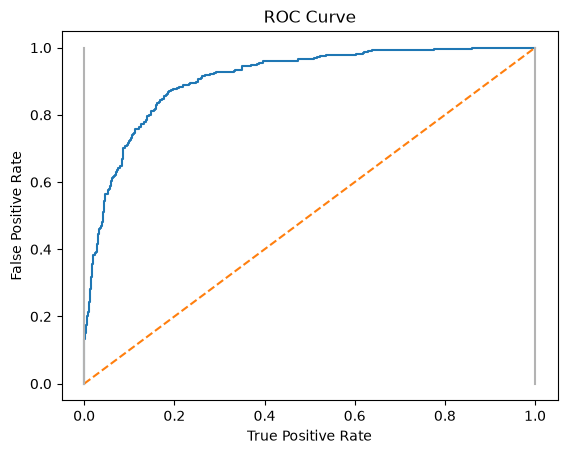

In [61]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split

# Generate the feature matrix and target vector
features, target = make_classification(
    n_samples=10000,
    n_features=10,
    n_classes=2,
    n_informative=3,
    random_state=3
)

# Create training and test sets
features_train, features_test, target_train, target_test = train_test_split(
features, target, test_size=0.1, random_state=1)

# Create a logistic regression classifier
logit = LogisticRegression()

# Learn the model on the training data
logit.fit(features_train, target_train)

# Get the predicted probabilities
target_probabilities = logit.predict_proba(features_test)[:,1]

# Create the false positive rate and true positive rate
false_positive_rate, true_positive_rate, threshold = roc_curve(
    target_test,
    target_probabilities
)

# Plot the ROC curve
plt.plot(false_positive_rate, true_positive_rate)
plt.plot([0, 1], ls="--")
plt.plot([0, 0], [1, 0], c=".7")
plt.plot([1, 1], [0, 1], c=".7")
plt.title("ROC Curve")
plt.xlabel("True Positive Rate")
plt.ylabel("False Positive Rate")
plt.show()

In [62]:
# Compute the AUC score
logit.predict_proba(features_test)[0:1]


array([[0.8689235, 0.1310765]])

In [63]:
print("Threshold:", threshold[124])
print("True Positive Rate:", true_positive_rate[124])
print("False Positive Rate:", false_positive_rate[124])


Threshold: 0.4981509475208573
True Positive Rate: 0.8367346938775511
False Positive Rate: 0.1627450980392157


In [64]:
print("Threshold:", threshold[49])
print("True Positive Rate:", true_positive_rate[49])
print("False Positive Rate:", false_positive_rate[49])

Threshold: 0.8058635463651345
True Positive Rate: 0.5653061224489796
False Positive Rate: 0.052941176470588235


In [65]:
# Compute the AUC score
roc_auc_score(target_test, target_probabilities)


0.9073429371748699

### Evaluation of predictions of a multi-class classifier

In [66]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification

# Сгенерироваf'lь маf'lрицу признаков и целевой векf'lор
features, target = make_classification(
    n_samples=10000,
    n_features=3,
    n_informative=3,
    n_redundant=0,
    n_classes=3,
    random_state=1,
)

# Create a logistic regression classifier
logit = LogisticRegression()
# Perform cross-validation with the accuracy scoring parameter
cross_val_score(logit, features, target, scoring="accuracy")

array([0.8405, 0.829 , 0.827 , 0.8155, 0.8205])

In [67]:
# Perform cross-validation with the precision scoring parameter
cross_val_score(logit, features, target, scoring="f1_macro")


array([0.84012014, 0.82895312, 0.82675308, 0.81515121, 0.82042629])

### Visualization of classification quality indicators

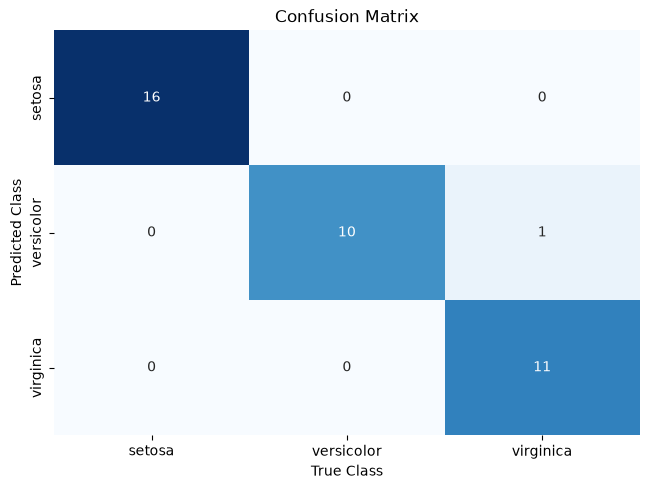

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import pandas as pd

# Load the iris dataset
iris = datasets.load_iris()

# Create the feature matrix
features = iris.data

# Create the target vector
target = iris.target

# Create the list of target class names
class_names = iris.target_names

# Create the training and test sets
features_train, features_test, target_train, target_test = train_test_split(
features, target, random_state=2)

# Create the logistic regression classifier
classifier = LogisticRegression()

# Train the model and make predictions
target_predicted = classifier.fit(features_train,
target_train).predict(features_test)

# Create the confusion matrix
matrix = confusion_matrix(target_test, target_predicted)

# Create the pandas DataFrame structure
dataframe = pd.DataFrame(matrix, index=class_names, columns=class_names)

# Create the heatmap
sns.heatmap(dataframe, annot=True, cbar=None, cmap="Blues")

plt.title("Confusion Matrix")
plt.tight_layout()
plt.xlabel("True Class")
plt.ylabel("Predicted Class")
plt.show()

### Evaluation of regression models

In [69]:
from sklearn.datasets import make_regression
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

# Generate the feature matrix and target vector
features, target = make_regression(
    n_samples=100,
    n_features=3,
    n_informative=3,
    n_targets=1,
    noise=50,
    coef=False,
    random_state=1,
)
# Create a linear regression model
ols = LinearRegression()
# Run cross-validation with the negative mean squared error scoring parameter
cross_val_score(ols, features, target, scoring="neg_mean_squared_error")

array([-1974.65337976, -2004.54137625, -3935.19355723, -1060.04361386,
       -1598.74104702])

In [70]:
# Run cross-validation with the R-squared scoring parameter
cross_val_score(ols, features, target, scoring="r2")


array([0.8622399 , 0.85838075, 0.74723548, 0.91354743, 0.84469331])

### Evaluation of clustering models

In [ ]:
import numpy as np
from sklearn.metrics import silhouette_score
from sklearn import datasets
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# Create the feature matrix
features, _ = make_blobs(
    n_samples=1000,
    n_features=10,
    centers=2,
    cluster_std=0.5,
    shuffle=True,
    random_state=1,
)

# Create the KMeans model and fit it to the data
model = KMeans(n_clusters=2, random_state=1).fit(features)

# Get the predicted cluster labels
target_predicted = model.labels_

# Evaluate the model
silhouette_score(features, target_predicted)

0.8916265564072141

### Creating your own evaluation metric

In [77]:
from sklearn.metrics import make_scorer, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.datasets import make_regression

# Create the feature matrix and target vector
features, target = make_regression(
    n_samples=100,
    n_features=3,
    random_state=1,
)

# Split the dataset into training and test sets
features_train, features_test, target_train, target_test = train_test_split(
    features, target, test_size=0.10, random_state=1)

# Create the custom metric
def custom_metric(target_test, target_predicted):
    # Calculate the R-squared value
    r2 = r2_score(target_test, target_predicted)
    # Return the R-squared value
    return r2

# Create the scorer and specify that a higher value is better
score = make_scorer(custom_metric, greater_is_better=True)

# Create the Ridge regression model
clf = Ridge()

# Train the Ridge regression model
model = clf.fit(features_train, target_train)

# Evaluate the model using the custom metric
score(model, features_test, target_test)

0.9997906102882058

In [78]:
# Create the Ridge regression model
target_predicted = model.predict(features_test)

# Compute the R-squared value
r2_score(target_test, target_predicted)

0.9997906102882058

### Visualization of the dependence of indicators on the training set size

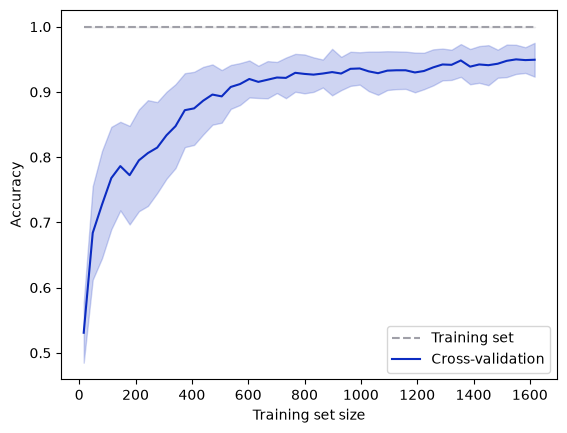

In [81]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_digits
from sklearn.model_selection import learning_curve

# Load the digits dataset
digits = load_digits()

# Create the feature matrix and target vector
features, target = digits.data, digits.target
# Create the training and test scores for cross-validation
# for different training set sizes
train_sizes, train_scores, test_scores = learning_curve(
    RandomForestClassifier(),  # Classifier
    features,  # Feature matrix
    target,  # Target vector
    cv=10,  # Count of blocks for cross-validation
    scoring="accuracy",  # Scoring metric
    n_jobs=-1,  # Use all CPU cores
    train_sizes=np.linspace(  # Обучающий набор
        0.01,
        1.0,
        50,  # 50 размеров
    ),
)

# Set the mean and standard deviation of the training set scores
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)

# Set the mean and standard deviation of the test set scores
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot the learning curves
plt.plot(train_sizes, train_mean, "--", color="#a0a0a8", label="Training set")
plt.plot(train_sizes, test_mean, color="#0c2cc2", label="Cross-validation")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color="#a0a0a8", alpha=0.2)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, color="#0c2cc2", alpha=0.2)
plt.xlabel("Training set size")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.show()

### Creating a text report with quality metrics

In [82]:
from sklearn import datasets
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Load the iris dataset
iris = datasets.load_iris()

# Create the target vector
target = iris.target

# Create the feature matrix
features = iris.data

# Create the list of target vector names
class_names = iris.target_names
# Create the training and test sets
features_train, features_test, target_train, target_test = train_test_split(
    features, target, random_state=0
)

# Create the logistic regression classifier
classifier = LogisticRegression()

# Train the model and make predictions
model = classifier.fit(features_train, target_train)
target_predicted = model.predict(features_test)

# Create the classification report
print(classification_report(
    target_test,
    target_predicted,
    target_names=class_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        13
  versicolor       1.00      0.94      0.97        16
   virginica       0.90      1.00      0.95         9

    accuracy                           0.97        38
   macro avg       0.97      0.98      0.97        38
weighted avg       0.98      0.97      0.97        38



### Visualizing the influence of hyperparameter values

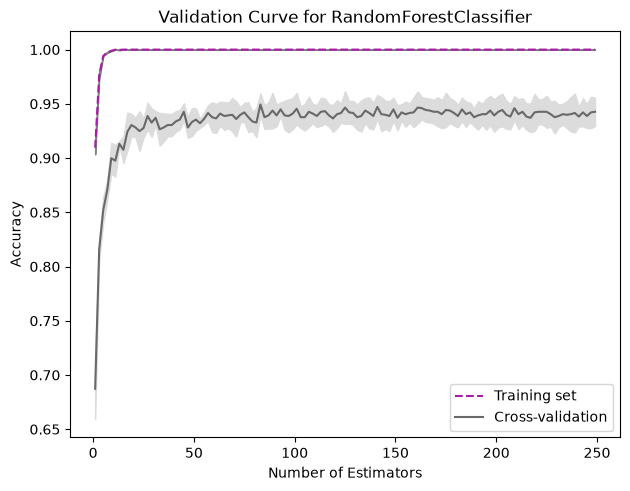

In [86]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import validation_curve

# Load the digits dataset
dtgtts = load_digits()

# Create the feature matrix and target vector
features, target = dtgtts.data, dtgtts.target

# Create the range of parameter values
param_range = np.arange(1, 250, 2)

# Create the training and test scores for cross-validation
train_scores, test_scores = validation_curve(
    RandomForestClassifier(),  # Classifier
    features, # Matrix of features
    target,  # Target vector
    param_name="n_estimators",  # Hyperparameter to evaluate
    param_range=param_range,  # Range of hyperparameter values
    cv=3,  # Number of folds
    scoring="accuracy",
    n_jobs=-1  # Use all CPU cores
)

# Compute the mean and standard deviation of the training set scores
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)

# Compute the mean and standard deviation of the test set scores
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot the validation curves
plt.plot(
    param_range, train_mean, label="Training set", linestyle="--", color="#ab1ba8"
)
plt.plot(param_range, test_mean, label="Cross-validation", color="dimgray")

# Plot the validation curves with standard deviation
plt.fill_between(param_range, train_mean - train_std,
                train_mean + train_std, color="gray")
plt.fill_between(param_range, test_mean - test_std,
                test_mean + test_std, color="gainsboro")

plt.xlabel("Number of Estimators")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.title("Validation Curve for RandomForestClassifier")
plt.legend(loc="best")
plt.show()